# Time to Resolution Prediction — Regression Task

## Objective

The objective of this task is to build machine learning regression models
to predict ticket resolution time.

The target variable used is `resolution_hour`, which was created as a proxy
for resolution duration due to inconsistencies observed in the original
`Time to Resolution` column.

Feature types used:

1. Tabular customer and ticket attributes
2. Text representation from ticket descriptions

Models implemented:

1. XGBoost Regressor
2. LightGBM Regressor

Evaluation metrics:

- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)
- R² Score

In [1]:
import pandas as pd
import numpy as np
import os
import pickle
import joblib

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import matplotlib.pyplot as plt
import seaborn as sns

import optuna


c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load Data
DATA_PATH = "../data/processed/res_time"

# Tabular + Text Features
X_train = pd.read_parquet(
    f"{DATA_PATH}/X_train.parquet"
)

X_val = pd.read_parquet(
    f"{DATA_PATH}/X_val.parquet"
)

X_test = pd.read_parquet(
    f"{DATA_PATH}/X_test.parquet"
)

# Target
y_train = pd.read_parquet(
    f"{DATA_PATH}/y_train.parquet"
)

y_val = pd.read_parquet(
    f"{DATA_PATH}/y_val.parquet"
)

y_test = pd.read_parquet(
    f"{DATA_PATH}/y_test.parquet"
)

In [3]:
# Verify data
print("Training Features:", X_train.shape)
print("Validation Features:", X_val.shape)
print("Testing Features:", X_test.shape)

print("\nTarget Preview:")
display(y_train.head())

Training Features: (1938, 9)
Validation Features: (415, 9)
Testing Features: (416, 9)

Target Preview:


,resolution_hour
0,3.0
1,8.0
2,23.0
3,15.0
4,4.0


## Feature Preparation

The regression dataset contains both structured features and textual
information.

Structured features include customer and ticket attributes, while the
ticket description text is transformed using TF-IDF.

Both feature representations are combined before training regression models.

In [4]:
# Extract text features
train_text = X_train["combined_text"]
val_text = X_val["combined_text"]
test_text = X_test["combined_text"]

In [5]:
# Extract tabular features
tabular_features = [
    "Customer Age",
    "Customer Gender Encoded",
    "Product Purchased Encoded",
    "Ticket Channel Encoded",
    "ticket_age_days",
    "char_count",
    "word_count",
    "avg_word_length"
]


X_train_tabular = X_train[tabular_features]

X_val_tabular = X_val[tabular_features]

X_test_tabular = X_test[tabular_features]


In [6]:
## Load TF-IDF Vectorizer

tfidf = joblib.load(
    '../models/tfidf_vectorizer.pkl'
)

In [7]:
# Transform text features
X_train_tfidf = tfidf.fit_transform(
    train_text
)

X_val_tfidf = tfidf.transform(
    val_text
)

X_test_tfidf = tfidf.transform(
    test_text
)


print("Train text shape:", X_train_tfidf.shape)
print("Validation text shape:", X_val_tfidf.shape)
print("Test text shape:", X_test_tfidf.shape)

Train text shape: (1938, 5000)
Validation text shape: (415, 5000)
Test text shape: (416, 5000)


In [8]:
print(X_train_tfidf.shape)
print(X_train_tabular.shape)

(1938, 5000)
(1938, 8)


In [9]:
# combine text and tabular features
from scipy.sparse import hstack

X_train_combined = hstack([
    X_train_tfidf,
    X_train_tabular.values
])

X_val_combined = hstack([
    X_val_tfidf,
    X_val_tabular.values
])

X_test_combined = hstack([
    X_test_tfidf,
    X_test_tabular.values
])

print(X_train_combined.shape)
print(X_val_combined.shape)
print(X_test_combined.shape)

(1938, 5008)
(415, 5008)
(416, 5008)


# Regression Model Training with Hyperparameter Optimization

This section trains regression models to predict `resolution_hour`.

The input feature matrix contains combined:

- Tabular ticket/customer features
- TF-IDF text features

Optuna is used for automatic hyperparameter optimization.

Models optimized:

1. XGBoost Regressor
2. LightGBM Regressor

Evaluation metric:
- RMSE: Measures average prediction error while penalizing large errors.
- MAE: Measures average absolute difference between actual and predicted values.
- R² Score: Measures the proportion of variance explained by the model.

## XGBoost with Hyperparameter Optimization

Optuna searches for the optimal combination of:

- number of estimators
- learning rate
- tree depth
- subsampling
- regularization parameters

In [10]:
# XGBoost
def xgb_objective(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            500
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            10
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            0,
            10
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            0,
            10
        ),

        "random_state": 42,
        "n_jobs": -1
    }


    model = XGBRegressor(**params)


    model.fit(
        X_train_combined,
        y_train
    )


    predictions = model.predict(
        X_val_combined
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            predictions
        )
    )

    return rmse

In [11]:
# Run Optuna Study
xgb_study = optuna.create_study(
    direction="minimize"
)


xgb_study.optimize(
    xgb_objective,
    n_trials=50
)

[I 2026-06-13 21:02:05,066] A new study created in memory with name: no-name-f5c1d010-2415-4ee7-a6af-c52d10e3a3ee
[I 2026-06-13 21:02:20,003] Trial 0 finished with value: 7.180996813846844 and parameters: {'n_estimators': 228, 'max_depth': 10, 'learning_rate': 0.019539780151900683, 'subsample': 0.6722593744724487, 'colsample_bytree': 0.8343065362718656, 'reg_alpha': 9.154532807187206, 'reg_lambda': 8.386410020484082}. Best is trial 0 with value: 7.180996813846844.
[I 2026-06-13 21:02:45,245] Trial 1 finished with value: 7.590320205065771 and parameters: {'n_estimators': 452, 'max_depth': 10, 'learning_rate': 0.08373634383709073, 'subsample': 0.770915242662055, 'colsample_bytree': 0.8712078221028603, 'reg_alpha': 8.592776826126757, 'reg_lambda': 3.5339799429917464}. Best is trial 0 with value: 7.180996813846844.
[I 2026-06-13 21:02:46,964] Trial 2 finished with value: 7.064505233340444 and parameters: {'n_estimators': 320, 'max_depth': 3, 'learning_rate': 0.014985879466871379, 'subsampl

In [12]:
# best parameters
xgb_study.best_params

{'n_estimators': 103,
 'max_depth': 3,
 'learning_rate': 0.010208272175631973,
 'subsample': 0.8109376581804412,
 'colsample_bytree': 0.7466935007233265,
 'reg_alpha': 8.626256749751775,
 'reg_lambda': 1.8097091477615757}

In [13]:
# Train XGBoost Model
best_xgb_params = xgb_study.best_params


best_xgb = XGBRegressor(
    **best_xgb_params,
    random_state=42,
    n_jobs=-1
)


best_xgb.fit(
    X_train_combined,
    y_train
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.7466935007233265
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegre

In [14]:
# Define evaluation function

def evaluate_regression_model(
    model,
    X_test,
    y_test,
    model_name
):

    # Generate predictions
    predictions = model.predict(
        X_test
    )


    # Calculate metrics
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )


    mae = mean_absolute_error(
        y_test,
        predictions
    )


    r2 = r2_score(
        y_test,
        predictions
    )


    results = {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2 Score": r2
    }


    return results, predictions

In [15]:
# Evaluate XGBoost
xgb_results, xgb_predictions = evaluate_regression_model(
    best_xgb,
    X_test_combined,
    y_test,
    "XGBoost Optuna"
)


xgb_results

{'Model': 'XGBoost Optuna',
 'RMSE': np.float64(6.862949144017398),
 'MAE': 5.9674272537231445,
 'R2 Score': -0.017798542976379395}

In [ ]:
# # Save XGBoost Model
# os.makedirs(
#     "../models/regression",
#     exist_ok=True
# )


# with open(
#     "../models/regression/xgboost_optuna.pkl",
#     "wb"
# ) as f:

#     pickle.dump(
#         best_xgb,
#         f
#     )

## LightGBM with Hyperparameter Optimization

In [17]:
# Define function
def lgbm_objective(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            500
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        "num_leaves": trial.suggest_int(
            "num_leaves",
            20,
            150
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            12
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            0,
            10
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            0,
            10
        ),

        "random_state":42
    }


    model = LGBMRegressor(**params)


    model.fit(
        X_train_combined,
        y_train
    )


    preds = model.predict(
        X_val_combined
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            preds
        )
    )

    return rmse

In [18]:
# Run Optuna Study
lgbm_study = optuna.create_study(
    direction="minimize"
)


lgbm_study.optimize(
    lgbm_objective,
    n_trials=50
)

[I 2026-06-13 21:05:15,439] A new study created in memory with name: no-name-3a602d4f-5ff9-4a27-8ae1-1873ffe865f8
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006493 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:05:20,348] Trial 0 finished with value: 7.642947230027977 and parameters: {'n_estimators': 361, 'learning_rate': 0.10250177832116297, 'num_leaves': 88, 'max_depth': 7, 'subsample': 0.7485467501470359, 'colsample_bytree': 0.8654477800686082, 'reg_alpha': 0.42390774248197705, 'reg_lambda': 7.069973178187199}. Best is trial 0 with value: 7.642947230027977.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:05:20,550] Trial 1 finished with value: 7.257616758436726 and parameters: {'n_estimators': 121, 'learning_rate': 0.16466686874604167, 'num_leaves': 128, 'max_depth': 3, 'subsample': 0.6189292510021346, 'colsample_bytree': 0.6384065722074116, 'reg_alpha': 9.

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:05:21,253] Trial 2 finished with value: 7.135936192800072 and parameters: {'n_estimators': 272, 'learning_rate': 0.013667020350763344, 'num_leaves': 145, 'max_depth': 10, 'subsample': 0.8721329766382229, 'colsample_bytree': 0.8686110223406291, 'reg_alpha': 8.256936644686586, 'reg_lambda': 9.697299981376}. Best is trial 2 with value: 7.135936192800072.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please cha

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005855 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:05:21,886] Trial 3 finished with value: 7.139182442504532 and parameters: {'n_estimators': 481, 'learning_rate': 0.017108596067504627, 'num_leaves': 44, 'max_depth': 4, 'subsample': 0.8716947040632421, 'colsample_bytree': 0.78564797159579, 'reg_alpha': 9.305151146627557, 'reg_lambda': 2.6312433953953795}. Best is trial 2 with value: 7.135936192800072.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please cha

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009669 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:05:22,883] Trial 4 finished with value: 7.732971704648166 and parameters: {'n_estimators': 374, 'learning_rate': 0.09943793968484602, 'num_leaves': 33, 'max_depth': 11, 'subsample': 0.6456081527306425, 'colsample_bytree': 0.732792452045783, 'reg_alpha': 9.347761428225192, 'reg_lambda': 8.909280559174432}. Best is trial 2 with value: 7.135936192800072.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011817 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:05:25,600] Trial 5 finished with value: 7.565891763377353 and parameters: {'n_estimators': 451, 'learning_rate': 0.12226941921092573, 'num_leaves': 51, 'max_depth': 4, 'subsample': 0.8763419186536112, 'colsample_bytree': 0.7295071867946376, 'reg_alpha': 4.246452424648401, 'reg_lambda': 2.7367843172674156}. Best is trial 2 with value: 7.135936192800072.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.217095 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:15:11,974] Trial 6 finished with value: 7.160256745097185 and parameters: {'n_estimators': 478, 'learning_rate': 0.014820472143433822, 'num_leaves': 52, 'max_depth': 5, 'subsample': 0.7627893796771077, 'colsample_bytree': 0.9174002056094065, 'reg_alpha': 2.1428196920788913, 'reg_lambda': 3.814884042244512}. Best is trial 2 with value: 7.135936192800072.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please c

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.296591 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:15:40,171] Trial 7 finished with value: 7.8061180507263135 and parameters: {'n_estimators': 459, 'learning_rate': 0.08579574165978106, 'num_leaves': 22, 'max_depth': 11, 'subsample': 0.6104614884252709, 'colsample_bytree': 0.6918829917820082, 'reg_alpha': 3.6127193030275926, 'reg_lambda': 0.21687264218216207}. Best is trial 2 with value: 7.135936192800072.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Pleas

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.159231 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:16:07,761] Trial 8 finished with value: 7.649477598534286 and parameters: {'n_estimators': 480, 'learning_rate': 0.07109043112851701, 'num_leaves': 104, 'max_depth': 8, 'subsample': 0.8730031541550689, 'colsample_bytree': 0.6376231924957397, 'reg_alpha': 3.3727930102603887, 'reg_lambda': 4.987843299131047}. Best is trial 2 with value: 7.135936192800072.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please c

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.117893 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:16:20,196] Trial 9 finished with value: 7.276568079780085 and parameters: {'n_estimators': 306, 'learning_rate': 0.055323070223651086, 'num_leaves': 83, 'max_depth': 5, 'subsample': 0.9739722265398525, 'colsample_bytree': 0.6054573482037079, 'reg_alpha': 9.911743118111328, 'reg_lambda': 3.345014851467656}. Best is trial 2 with value: 7.135936192800072.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please ch

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.126707 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:16:30,519] Trial 10 finished with value: 7.228442684423836 and parameters: {'n_estimators': 157, 'learning_rate': 0.03466793117766732, 'num_leaves': 143, 'max_depth': 9, 'subsample': 0.9969547632965121, 'colsample_bytree': 0.9685472731849522, 'reg_alpha': 6.767282512083351, 'reg_lambda': 8.98408439848966}. Best is trial 2 with value: 7.135936192800072.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please ch

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.127190 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:16:48,035] Trial 11 finished with value: 7.106500350387862 and parameters: {'n_estimators': 224, 'learning_rate': 0.01047586272999889, 'num_leaves': 119, 'max_depth': 12, 'subsample': 0.8821980677698441, 'colsample_bytree': 0.8138603525115867, 'reg_alpha': 7.436338282974866, 'reg_lambda': 6.018064302781088}. Best is trial 11 with value: 7.106500350387862.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.127309 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:17:05,473] Trial 12 finished with value: 7.14074862593729 and parameters: {'n_estimators': 225, 'learning_rate': 0.012725108116818467, 'num_leaves': 149, 'max_depth': 12, 'subsample': 0.8040853566441437, 'colsample_bytree': 0.82820653501071, 'reg_alpha': 6.65246995745212, 'reg_lambda': 6.497291960107262}. Best is trial 11 with value: 7.106500350387862.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please ch

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.124601 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:17:19,918] Trial 13 finished with value: 7.223210419651444 and parameters: {'n_estimators': 238, 'learning_rate': 0.025217028460414875, 'num_leaves': 119, 'max_depth': 10, 'subsample': 0.9357140061839022, 'colsample_bytree': 0.8755287717654322, 'reg_alpha': 7.118357060169518, 'reg_lambda': 9.95312846975071}. Best is trial 11 with value: 7.106500350387862.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.119082 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:17:34,774] Trial 14 finished with value: 7.090143903574496 and parameters: {'n_estimators': 212, 'learning_rate': 0.010441524342479146, 'num_leaves': 125, 'max_depth': 12, 'subsample': 0.8144261281313345, 'colsample_bytree': 0.8036418993152037, 'reg_alpha': 7.950214589868828, 'reg_lambda': 6.545062170151332}. Best is trial 14 with value: 7.090143903574496.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Pleas

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.139672 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:17:46,745] Trial 15 finished with value: 7.089936580448131 and parameters: {'n_estimators': 191, 'learning_rate': 0.010575193912654416, 'num_leaves': 111, 'max_depth': 12, 'subsample': 0.8123707931691566, 'colsample_bytree': 0.7931868088910778, 'reg_alpha': 5.430390625079056, 'reg_lambda': 6.65703036802392}. Best is trial 15 with value: 7.089936580448131.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.155605 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:17:57,329] Trial 16 finished with value: 7.191350561874909 and parameters: {'n_estimators': 168, 'learning_rate': 0.023806412436257782, 'num_leaves': 93, 'max_depth': 12, 'subsample': 0.6998102448540893, 'colsample_bytree': 0.7700546898900299, 'reg_alpha': 5.4691255105631456, 'reg_lambda': 7.664159234951801}. Best is trial 15 with value: 7.089936580448131.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Pleas

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.102418 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:18:06,552] Trial 17 finished with value: 7.0806726645980005 and parameters: {'n_estimators': 174, 'learning_rate': 0.01000154217054989, 'num_leaves': 71, 'max_depth': 10, 'subsample': 0.8108384694394718, 'colsample_bytree': 0.9505909106409498, 'reg_alpha': 5.615174902669652, 'reg_lambda': 4.903124518750558}. Best is trial 17 with value: 7.0806726645980005.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Pleas

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.443561 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:18:16,837] Trial 18 finished with value: 7.085267610328527 and parameters: {'n_estimators': 106, 'learning_rate': 0.022078125624141475, 'num_leaves': 70, 'max_depth': 8, 'subsample': 0.8102116166291448, 'colsample_bytree': 0.9598458310144792, 'reg_alpha': 5.392406086003671, 'reg_lambda': 4.6849672410569445}. Best is trial 17 with value: 7.0806726645980005.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Pleas

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.123541 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:18:25,031] Trial 19 finished with value: 7.149080981743558 and parameters: {'n_estimators': 134, 'learning_rate': 0.0378543060281383, 'num_leaves': 69, 'max_depth': 7, 'subsample': 0.7202545523436018, 'colsample_bytree': 0.9901530485523318, 'reg_alpha': 5.445982116800815, 'reg_lambda': 4.6173491814472225}. Best is trial 17 with value: 7.0806726645980005.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please 

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.138508 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:18:33,104] Trial 20 finished with value: 7.090033275194008 and parameters: {'n_estimators': 103, 'learning_rate': 0.020933494787978547, 'num_leaves': 70, 'max_depth': 8, 'subsample': 0.9263836367401261, 'colsample_bytree': 0.9379390491603676, 'reg_alpha': 1.757136440757053, 'reg_lambda': 5.133084781434242}. Best is trial 17 with value: 7.0806726645980005.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.123320 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:18:45,178] Trial 21 finished with value: 7.952663886337412 and parameters: {'n_estimators': 180, 'learning_rate': 0.29473299879665743, 'num_leaves': 70, 'max_depth': 10, 'subsample': 0.8154304554304803, 'colsample_bytree': 0.9238610016816953, 'reg_alpha': 5.4435150348874535, 'reg_lambda': 5.54354871373773}. Best is trial 17 with value: 7.0806726645980005.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.108708 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:18:58,585] Trial 22 finished with value: 7.122134849058353 and parameters: {'n_estimators': 183, 'learning_rate': 0.018386994352961455, 'num_leaves': 103, 'max_depth': 9, 'subsample': 0.7828434603961489, 'colsample_bytree': 0.9627843405076327, 'reg_alpha': 4.628409733676298, 'reg_lambda': 4.132042482593127}. Best is trial 17 with value: 7.0806726645980005.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Pleas

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.128014 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:19:12,731] Trial 23 finished with value: 7.188619029113401 and parameters: {'n_estimators': 139, 'learning_rate': 0.030798567958469407, 'num_leaves': 63, 'max_depth': 11, 'subsample': 0.8264299504282633, 'colsample_bytree': 0.9101047406157606, 'reg_alpha': 5.965375895402569, 'reg_lambda': 7.805395376502161}. Best is trial 17 with value: 7.0806726645980005.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Pleas

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.187197 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:19:28,664] Trial 24 finished with value: 7.1267269489182885 and parameters: {'n_estimators': 266, 'learning_rate': 0.010180557910300194, 'num_leaves': 83, 'max_depth': 9, 'subsample': 0.8369679305437862, 'colsample_bytree': 0.9833856946316316, 'reg_alpha': 4.402125879750864, 'reg_lambda': 7.616048758384819}. Best is trial 17 with value: 7.0806726645980005.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Pleas

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.113912 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:19:33,942] Trial 25 finished with value: 7.150484288187735 and parameters: {'n_estimators': 111, 'learning_rate': 0.04719667189447753, 'num_leaves': 103, 'max_depth': 7, 'subsample': 0.6883888621036544, 'colsample_bytree': 0.8950334434061848, 'reg_alpha': 6.047751991605676, 'reg_lambda': 1.1210613360220654}. Best is trial 17 with value: 7.0806726645980005.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Pleas

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.111933 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:19:41,977] Trial 26 finished with value: 7.094348978687919 and parameters: {'n_estimators': 194, 'learning_rate': 0.014511614543371269, 'num_leaves': 57, 'max_depth': 8, 'subsample': 0.7416298620423156, 'colsample_bytree': 0.8377962537578849, 'reg_alpha': 2.7961945680733664, 'reg_lambda': 5.754738056532122}. Best is trial 17 with value: 7.0806726645980005.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.136389 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:19:50,300] Trial 27 finished with value: 7.189477523619098 and parameters: {'n_estimators': 150, 'learning_rate': 0.028072656417590474, 'num_leaves': 39, 'max_depth': 11, 'subsample': 0.7800836462161443, 'colsample_bytree': 0.9446233176452911, 'reg_alpha': 4.817500762427678, 'reg_lambda': 4.179011386515894}. Best is trial 17 with value: 7.0806726645980005.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Pleas

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.089548 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:19:56,551] Trial 28 finished with value: 7.055816442353257 and parameters: {'n_estimators': 100, 'learning_rate': 0.01894726042833552, 'num_leaves': 78, 'max_depth': 10, 'subsample': 0.9207617496074249, 'colsample_bytree': 0.7586022587708742, 'reg_alpha': 6.270835616715287, 'reg_lambda': 3.4691272023488686}. Best is trial 28 with value: 7.055816442353257.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.339830 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:20:54,684] Trial 29 finished with value: 7.095037628377544 and parameters: {'n_estimators': 105, 'learning_rate': 0.019645653994772628, 'num_leaves': 91, 'max_depth': 9, 'subsample': 0.9591943835778372, 'colsample_bytree': 0.9993406740156605, 'reg_alpha': 6.164115312723043, 'reg_lambda': 1.5210423952777585}. Best is trial 28 with value: 7.055816442353257.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.137212 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:21:00,448] Trial 30 finished with value: 7.174093519597084 and parameters: {'n_estimators': 145, 'learning_rate': 0.04690264176564045, 'num_leaves': 78, 'max_depth': 6, 'subsample': 0.9106782932057423, 'colsample_bytree': 0.8433763632360637, 'reg_alpha': 0.5385889768738563, 'reg_lambda': 3.5457910394587673}. Best is trial 28 with value: 7.055816442353257.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.249739 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:21:18,612] Trial 31 finished with value: 7.097246542115093 and parameters: {'n_estimators': 193, 'learning_rate': 0.012524334271893095, 'num_leaves': 78, 'max_depth': 10, 'subsample': 0.832530953773656, 'colsample_bytree': 0.7419604956431071, 'reg_alpha': 5.070299896997601, 'reg_lambda': 4.743521466973158}. Best is trial 28 with value: 7.055816442353257.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please 

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.177057 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:21:27,314] Trial 32 finished with value: 7.053591057242435 and parameters: {'n_estimators': 121, 'learning_rate': 0.01638078704942503, 'num_leaves': 94, 'max_depth': 7, 'subsample': 0.8516568311766594, 'colsample_bytree': 0.6908769958557869, 'reg_alpha': 6.465395814508991, 'reg_lambda': 6.69656780215434}. Best is trial 32 with value: 7.053591057242435.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please ch

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.121562 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:21:40,392] Trial 33 finished with value: 7.04694904852883 and parameters: {'n_estimators': 124, 'learning_rate': 0.016498646065483746, 'num_leaves': 98, 'max_depth': 7, 'subsample': 0.8544372701554641, 'colsample_bytree': 0.6664513622559216, 'reg_alpha': 8.22932959532375, 'reg_lambda': 5.522169150801581}. Best is trial 33 with value: 7.04694904852883.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please cha

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.723625 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:21:54,918] Trial 34 finished with value: 7.0402158619723485 and parameters: {'n_estimators': 130, 'learning_rate': 0.017642790307612694, 'num_leaves': 96, 'max_depth': 7, 'subsample': 0.8456769692722189, 'colsample_bytree': 0.6851417762585702, 'reg_alpha': 8.357837105739872, 'reg_lambda': 7.097937498799314}. Best is trial 34 with value: 7.0402158619723485.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Pleas

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.195333 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:22:05,993] Trial 35 finished with value: 7.039617931021422 and parameters: {'n_estimators': 124, 'learning_rate': 0.01667434516835412, 'num_leaves': 95, 'max_depth': 6, 'subsample': 0.850580343854712, 'colsample_bytree': 0.6827965736650448, 'reg_alpha': 8.55891112905004, 'reg_lambda': 8.369939419183575}. Best is trial 35 with value: 7.039617931021422.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please cha

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.105767 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:22:26,437] Trial 36 finished with value: 7.041407992497628 and parameters: {'n_estimators': 131, 'learning_rate': 0.016902972244847072, 'num_leaves': 96, 'max_depth': 6, 'subsample': 0.8502560549992527, 'colsample_bytree': 0.6903383745649116, 'reg_alpha': 8.649188338252081, 'reg_lambda': 8.570597953452774}. Best is trial 35 with value: 7.039617931021422.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please 

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.858043 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:22:34,039] Trial 37 finished with value: 7.040670614238958 and parameters: {'n_estimators': 128, 'learning_rate': 0.016307044841336514, 'num_leaves': 98, 'max_depth': 6, 'subsample': 0.897784908667894, 'colsample_bytree': 0.6875062025697469, 'reg_alpha': 8.756906411602413, 'reg_lambda': 8.436361204508248}. Best is trial 35 with value: 7.039617931021422.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please c

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.123327 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:22:39,261] Trial 38 finished with value: 7.090779425187224 and parameters: {'n_estimators': 144, 'learning_rate': 0.026286093543990925, 'num_leaves': 112, 'max_depth': 6, 'subsample': 0.8986199958208018, 'colsample_bytree': 0.7014535753703774, 'reg_alpha': 8.73593554680238, 'reg_lambda': 8.597850438092145}. Best is trial 35 with value: 7.039617931021422.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.131389 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:22:47,366] Trial 39 finished with value: 7.045723497974142 and parameters: {'n_estimators': 165, 'learning_rate': 0.013488716795763921, 'num_leaves': 111, 'max_depth': 6, 'subsample': 0.8575850694925138, 'colsample_bytree': 0.6513784828074503, 'reg_alpha': 8.86854024653652, 'reg_lambda': 8.417925594501428}. Best is trial 35 with value: 7.039617931021422.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please 

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.146449 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:22:56,609] Trial 40 finished with value: 7.151960583559427 and parameters: {'n_estimators': 390, 'learning_rate': 0.03320688526631672, 'num_leaves': 139, 'max_depth': 3, 'subsample': 0.8832662910239746, 'colsample_bytree': 0.707560004442512, 'reg_alpha': 9.902791461964068, 'reg_lambda': 9.354973845650834}. Best is trial 35 with value: 7.039617931021422.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please c

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.104033 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:23:04,099] Trial 41 finished with value: 7.046950059434934 and parameters: {'n_estimators': 160, 'learning_rate': 0.014582717245389525, 'num_leaves': 111, 'max_depth': 6, 'subsample': 0.8497318456906195, 'colsample_bytree': 0.6419062443834843, 'reg_alpha': 8.920330274814896, 'reg_lambda': 8.325832108692476}. Best is trial 35 with value: 7.039617931021422.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.118494 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:23:10,364] Trial 42 finished with value: 7.026990760200247 and parameters: {'n_estimators': 128, 'learning_rate': 0.012538418412419627, 'num_leaves': 87, 'max_depth': 5, 'subsample': 0.8988883275000809, 'colsample_bytree': 0.6721899955364736, 'reg_alpha': 7.8009577578693845, 'reg_lambda': 8.223894049686555}. Best is trial 42 with value: 7.026990760200247.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.118685 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:23:16,071] Trial 43 finished with value: 7.043861341067025 and parameters: {'n_estimators': 130, 'learning_rate': 0.016653394025792394, 'num_leaves': 84, 'max_depth': 5, 'subsample': 0.9021799925119847, 'colsample_bytree': 0.6118481616764804, 'reg_alpha': 7.721155441161405, 'reg_lambda': 7.222449312094557}. Best is trial 42 with value: 7.026990760200247.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please 

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.142776 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:23:20,691] Trial 44 finished with value: 7.024419556392193 and parameters: {'n_estimators': 128, 'learning_rate': 0.012139589926899997, 'num_leaves': 96, 'max_depth': 5, 'subsample': 0.8817404768342474, 'colsample_bytree': 0.6709300348132281, 'reg_alpha': 8.405093485632959, 'reg_lambda': 9.506994203578083}. Best is trial 44 with value: 7.024419556392193.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please 

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.105556 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:23:25,745] Trial 45 finished with value: 7.024671324688648 and parameters: {'n_estimators': 152, 'learning_rate': 0.011869873753747897, 'num_leaves': 101, 'max_depth': 4, 'subsample': 0.9482142063347497, 'colsample_bytree': 0.6693935951658229, 'reg_alpha': 9.45602683533404, 'reg_lambda': 9.336962940709771}. Best is trial 44 with value: 7.024419556392193.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please 

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.218732 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:23:31,635] Trial 46 finished with value: 7.05494370735789 and parameters: {'n_estimators': 204, 'learning_rate': 0.012952562008755003, 'num_leaves': 88, 'max_depth': 4, 'subsample': 0.9529805532392004, 'colsample_bytree': 0.6671262716261293, 'reg_alpha': 9.352017521402434, 'reg_lambda': 9.339235107452264}. Best is trial 44 with value: 7.024419556392193.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please c

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.294981 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:23:41,765] Trial 47 finished with value: 7.0586538495133 and parameters: {'n_estimators': 241, 'learning_rate': 0.011789545889375861, 'num_leaves': 117, 'max_depth': 4, 'subsample': 0.9817822126291665, 'colsample_bytree': 0.7174325849427067, 'reg_alpha': 7.317118496187806, 'reg_lambda': 9.53967084937558}. Best is trial 44 with value: 7.024419556392193.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please ch

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.119493 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:23:54,302] Trial 48 finished with value: 7.087240053603571 and parameters: {'n_estimators': 328, 'learning_rate': 0.011738554363318632, 'num_leaves': 130, 'max_depth': 5, 'subsample': 0.9365327117488476, 'colsample_bytree': 0.624299328730282, 'reg_alpha': 9.498674076089763, 'reg_lambda': 9.041200084271036}. Best is trial 44 with value: 7.024419556392193.
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please 

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.509837 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-06-13 21:24:03,014] Trial 49 finished with value: 7.046358096737577 and parameters: {'n_estimators': 155, 'learning_rate': 0.021748300804450282, 'num_leaves': 105, 'max_depth': 3, 'subsample': 0.8748127861250448, 'colsample_bytree': 0.6673176507756471, 'reg_alpha': 8.15891817199752, 'reg_lambda': 8.044036554958677}. Best is trial 44 with value: 7.024419556392193.


In [19]:
# Best Parameters
lgbm_study.best_params

{'n_estimators': 128,
 'learning_rate': 0.012139589926899997,
 'num_leaves': 96,
 'max_depth': 5,
 'subsample': 0.8817404768342474,
 'colsample_bytree': 0.6709300348132281,
 'reg_alpha': 8.405093485632959,
 'reg_lambda': 9.506994203578083}

In [20]:
# Train LightGBM Model
best_lgbm_params = lgbm_study.best_params


best_lgbm = LGBMRegressor(
    **best_lgbm_params,
    random_state=42,
    n_jobs=-1
)


best_lgbm.fit(
    X_train_combined,
    y_train
)

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.601688 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20246
[LightGBM] [Info] Number of data points in the train set: 1938, number of used features: 650
[LightGBM] [Info] Start training from score 11.600103
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

,boosting_type,'gbdt'
,num_leaves,96
,max_depth,5
,learning_rate,0.012139589926899997
,n_estimators,128
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
# Evaluate Light GBM
lgbm_results, lgbm_predictions = evaluate_regression_model(
    best_lgbm,
    X_test_combined,
    y_test,
    "LightGBM Optuna"
)

lgbm_results

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


{'Model': 'XGBoost Optuna',
 'RMSE': np.float64(6.894324758094116),
 'MAE': 5.992617577574473,
 'R2 Score': -0.027126011436317876}

## Experiment Tracking with MLflow

The regression experiments are tracked using MLflow.

Each model run stores:
- Hyperparameters
- Evaluation metrics
- Trained model artifacts

In [22]:
import mlflow
import mlflow.sklearn
import dagshub

In [ ]:
https://dagshub.com/armaaz.au.stats/AI-Powered-Customer-Support-Intelligence-Platform.git

In [23]:
dagshub.init(
    repo_owner='armaaz.au.stats',
    repo_name='AI-Powered-Customer-Support-Intelligence-Platform',
    mlflow=True
)

Accessing as armaaz.au.stats

Initialized MLflow to track repo "armaaz.au.stats/AI-Powered-Customer-Support-Intelligence-Platform"

Repository armaaz.au.stats/AI-Powered-Customer-Support-Intelligence-Platform initialized!

In [24]:
# Set experiment
mlflow.set_experiment(
    "Regression Models"
)

2026/06/13 22:32:33 INFO mlflow.tracking.fluent: Experiment with name 'Regression Models' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/9989abe09ea145a9af1a6678157f0f49', creation_time=1781370155863, experiment_id='4', last_update_time=1781370155863, lifecycle_stage='active', name='Regression Models', tags={}, workspace='default'>

In [25]:
# Log XGBoost Model
with mlflow.start_run(
    run_name="XGBoost_Optuna_Baseline"
):

    # Log model parameters
    mlflow.log_params(
        xgb_study.best_params
    )


    # Log metrics
    mlflow.log_metric(
        "RMSE",
        float(xgb_results["RMSE"])
    )

    mlflow.log_metric(
        "MAE",
        float(xgb_results["MAE"])
    )

    mlflow.log_metric(
        "R2_Score",
        float(xgb_results["R2 Score"])
    )


    # Save model temporarily
    xgb_model_path = (
        "../models/regression/"
        "xgboost_optuna_baseline.pkl"
    )


    with open(
        xgb_model_path,
        "wb"
    ) as f:
        pickle.dump(
            best_xgb,
            f
        )


    # Log model artifact
    mlflow.log_artifact(
        xgb_model_path,
        artifact_path="models"
    )


print("XGBoost logged successfully")

🏃 View run XGBoost_Optuna_Baseline at: https://dagshub.com/armaaz.au.stats/AI-Powered-Customer-Support-Intelligence-Platform.mlflow/#/experiments/4/runs/2c3c3cfdd1364b8cb3701f73013c476b
🧪 View experiment at: https://dagshub.com/armaaz.au.stats/AI-Powered-Customer-Support-Intelligence-Platform.mlflow/#/experiments/4
XGBoost logged successfully


In [26]:
# Log LightGBM Model
with mlflow.start_run(
    run_name="LightGBM_Optuna_Baseline"
):

    # Log parameters
    mlflow.log_params(
        lgbm_study.best_params
    )


    # Log metrics
    mlflow.log_metric(
        "RMSE",
        float(lgbm_results["RMSE"])
    )

    mlflow.log_metric(
        "MAE",
        float(lgbm_results["MAE"])
    )

    mlflow.log_metric(
        "R2_Score",
        float(lgbm_results["R2 Score"])
    )


    # Save model

    lgbm_model_path = (
        "../models/regression/"
        "lightgbm_optuna_baseline.pkl"
    )


    with open(
        lgbm_model_path,
        "wb"
    ) as f:
        pickle.dump(
            best_lgbm,
            f
        )


    mlflow.log_artifact(
        lgbm_model_path,
        artifact_path="models"
    )


print("LightGBM logged successfully")

🏃 View run LightGBM_Optuna_Baseline at: https://dagshub.com/armaaz.au.stats/AI-Powered-Customer-Support-Intelligence-Platform.mlflow/#/experiments/4/runs/5d4556f5428c47e19a74c75b272c068f
🧪 View experiment at: https://dagshub.com/armaaz.au.stats/AI-Powered-Customer-Support-Intelligence-Platform.mlflow/#/experiments/4
LightGBM logged successfully


## Regression Results

Two gradient boosting regression models were optimized using Optuna.

XGBoost achieved the best performance with:

- RMSE: 6.86 hours
- MAE: 5.97 hours
- R²: -0.018

The negative R² indicates that available features have limited ability to explain
variation in resolution time, suggesting that additional operational features
may be required.

## Diving into the negative R2 problem to get better model results

In [27]:
y_train.describe()

,resolution_hour
count,1938.000000
mean,11.600103
std,6.842240
min,0.000000
25%,6.000000
50%,12.000000
75%,18.000000
max,23.000000


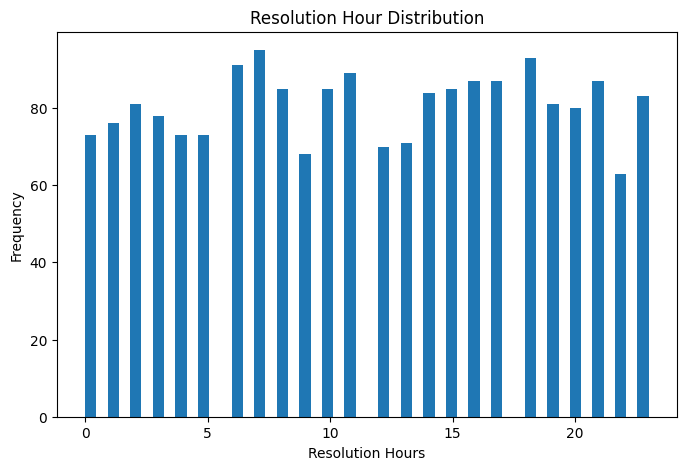

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(y_train, bins=50)
plt.xlabel("Resolution Hours")
plt.ylabel("Frequency")
plt.title("Resolution Hour Distribution")
plt.show()

In [ ]:
# # Save XGBoost Model
# os.makedirs(
#     "../models/regression",
#     exist_ok=True
# )


# with open(
#     "../models/regression/xgboost_optuna.pkl",
#     "wb"
# ) as f:

#     pickle.dump(
#         best_xgb,
#         f
#     )

In [ ]:
# # Save XGBoost Results
# os.makedirs(
#     "../model_results/regression",
#     exist_ok=True
# )
# xgb_results.to_csv("../model_results/regression/xgb_regression_results.csv")

In [ ]:
# # Save LightGBM Model

# os.makedirs(
#     "../models/regression",
#     exist_ok=True
# )


# with open(
#     "../models/regression/lbgm_optuna.pkl",
#     "wb"
# ) as f:

#     pickle.dump(
#         best_lgbm,
#         f
#     )

In [ ]:
# # Save LightGBM Results
# os.makedirs(
#     "../model_results/regression",
#     exist_ok=True
# )
# lgbm_results.to_csv("../model_results/regression/lgbm_regression_results.csv")